Session summary:
n_licks       1851
n_face_pcs     500
n_m2            73
n_ofc           72
n_olf           66
dtype: int64 

Raw columns:
['time all licks', 'first lick', 'last lick', 'reward', 'last reward', 'trial number', 'consecutive failures'] 

Missing values per column:
time all licks           13
first lick                0
last lick                 0
reward                    0
last reward               0
trial number              0
consecutive failures    100
dtype: int64 

Cleaned behavioral rows: 1751
   time all licks  first lick  last lick  reward  last reward  trial number  \
0       28.939108           1          0       1            0             1   
1       29.056333           0          0       1            0             1   
2       29.173558           0          0       1            0             1   
3       29.289781           0          0       0            0             1   
4       29.407006           0          0       1            0             1   

   c

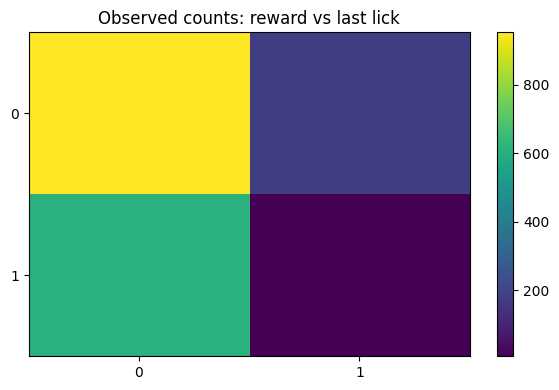

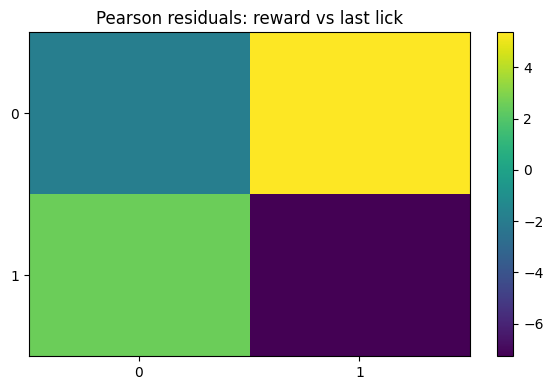

Chi-square test: cf_bin vs last lick
n = 1751
chi2 = 312.6607
dof = 4
p-value = 2.01096e-66

Observed counts:
last lick    0    1
cf_bin             
0          610    7
1          223    3
2          179    3
3          165   10
4+         386  165

Expected counts:
last lick       0      1
cf_bin                  
0          550.75  66.25
1          201.74  24.26
2          162.46  19.54
3          156.21  18.79
4+         491.84  59.16

Cramer's V: 0.4226
Cells with expected count < 5: 0/10


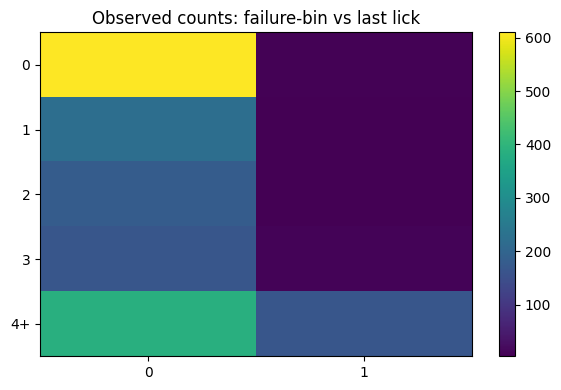

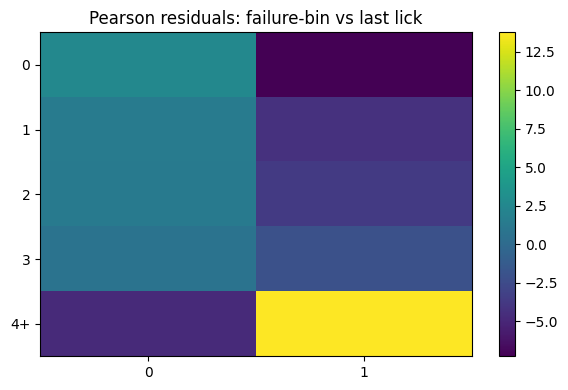

Chi-square test: first lick vs reward
n = 1751
chi2 = 331.9790
dof = 1
p-value = 3.56259e-74

Observed counts:
reward         0    1
first lick           
0           1125  438
1              9  179

Expected counts:
reward            0       1
first lick                 
0           1012.25  550.75
1            121.75   66.25

Cramer's V: 0.4354
Cells with expected count < 5: 0/4

Quick interpretation guide:
- Large chi2 + small p-value => evidence of association.
- Cramer's V gives effect size (small ~ weak, larger ~ stronger).
- Pearson residuals show which cells drive the association.
  Positive residual: observed > expected.
  Negative residual: observed < expected.


In [1]:
# ============================================
# Chi-squared exploratory analysis notebook
# Facial expressions / foraging task dataset
# ============================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt


# ----------------------------
# 1. Data loading
# ----------------------------

def _to_str_list(x):
    arr = np.ravel(x)
    out = []
    for item in arr:
        if isinstance(item, bytes):
            out.append(item.decode("utf-8"))
        else:
            out.append(str(item))
    return out


def load_mouse_session(mat_path):
    """
    Load one Mouse_Ephys_*.mat file.

    Returns:
        dict with:
            - licks: DataFrame
            - face: ndarray
            - m2: ndarray or None
            - ofc: ndarray or None
            - olf: ndarray or None
    """
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    colnames = _to_str_list(mat["licks_mat_columnName"])
    licks = pd.DataFrame(np.asarray(mat["licks_mat"]), columns=colnames)

    face = np.asarray(mat["FacePCs"]) if "FacePCs" in mat else None
    m2 = np.asarray(mat["Neurons_M2"]) if "Neurons_M2" in mat else None
    ofc = np.asarray(mat["Neurons_OFC"]) if "Neurons_OFC" in mat else None
    olf = np.asarray(mat["Neurons_OLF"]) if "Neurons_OLF" in mat else None

    return {
        "licks": licks,
        "face": face,
        "m2": m2,
        "ofc": ofc,
        "olf": olf,
    }


def summarize_session(data):
    return pd.Series({
        "n_licks": len(data["licks"]),
        "n_face_pcs": 0 if data["face"] is None else data["face"].shape[1],
        "n_m2": 0 if data["m2"] is None else data["m2"].shape[1],
        "n_ofc": 0 if data["ofc"] is None else data["ofc"].shape[1],
        "n_olf": 0 if data["olf"] is None else data["olf"].shape[1],
    })


# ----------------------------
# 2. Cleaning / preprocessing
# ----------------------------

def clean_licks_for_behavior(licks):
    """
    Minimal cleaning for behavioral chi-square analyses.

    We keep rows where:
    - trial number is defined and > 0
    - time is defined

    This removes startup / padding-like rows.
    """
    df = licks.copy()

    required_cols = ["trial number", "time all licks"]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    mask = (
        df["trial number"].notna() &
        (df["trial number"] > 0) &
        df["time all licks"].notna()
    )

    df = df.loc[mask].copy().reset_index(drop=True)

    # Cast obvious binary/integer-like columns
    for c in ["first lick", "last lick", "reward", "last reward", "trial number"]:
        if c in df.columns:
            df[c] = df[c].astype(int)

    # consecutive failures may still contain NaN on some rows
    if "consecutive failures" in df.columns:
        # keep as float for now; later analyses can subset to non-missing rows
        pass

    return df


def add_failure_bins(df):
    """
    Create a categorical binned version of consecutive failures
    for contingency-table analyses.
    """
    out = df.copy()

    if "consecutive failures" not in out.columns:
        raise ValueError("Missing column: consecutive failures")

    cf = out["consecutive failures"]

    # You can tweak these bins later depending on distribution
    bins = [-np.inf, 0, 1, 2, 3, np.inf]
    labels = ["0", "1", "2", "3", "4+"]

    out["cf_bin"] = pd.cut(cf, bins=bins, labels=labels)
    return out


# ----------------------------
# 3. Chi-square helpers
# ----------------------------

def chi_square_independence(df, row_var, col_var, dropna=True):
    """
    Perform chi-square test of independence and return:
    - contingency table
    - expected counts
    - Pearson residuals
    - standardized contribution table
    """
    tmp = df[[row_var, col_var]].copy()
    if dropna:
        tmp = tmp.dropna()

    contingency = pd.crosstab(tmp[row_var], tmp[col_var])

    chi2, p, dof, expected = chi2_contingency(contingency, correction=False)

    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )

    pearson_resid = (contingency - expected_df) / np.sqrt(expected_df)
    contrib = (contingency - expected_df) ** 2 / expected_df

    result = {
        "row_var": row_var,
        "col_var": col_var,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "n": contingency.to_numpy().sum(),
        "contingency": contingency,
        "expected": expected_df,
        "pearson_residuals": pearson_resid,
        "cell_contributions": contrib,
    }
    return result


def cramers_v(contingency):
    """
    Cramer's V effect size for a contingency table.
    """
    chi2, p, dof, expected = chi2_contingency(contingency, correction=False)
    n = contingency.to_numpy().sum()
    r, c = contingency.shape
    k = min(r - 1, c - 1)
    if k <= 0 or n == 0:
        return np.nan
    return np.sqrt(chi2 / (n * k))


def print_chi_square_summary(res):
    print(f"Chi-square test: {res['row_var']} vs {res['col_var']}")
    print(f"n = {res['n']}")
    print(f"chi2 = {res['chi2']:.4f}")
    print(f"dof = {res['dof']}")
    print(f"p-value = {res['p_value']:.6g}")
    print("\nObserved counts:")
    print(res["contingency"])
    print("\nExpected counts:")
    print(res["expected"].round(2))


def plot_contingency_heatmap(df, title, cmap="Blues"):
    plt.figure(figsize=(6, 4))
    plt.imshow(df.values, aspect="auto")
    plt.xticks(range(df.shape[1]), df.columns)
    plt.yticks(range(df.shape[0]), df.index)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()


def check_expected_counts(res, threshold=5):
    exp = res["expected"].to_numpy()
    small = (exp < threshold).sum()
    total = exp.size
    print(f"Cells with expected count < {threshold}: {small}/{total}")
    return small, total


# ----------------------------
# 4. Run on one file
# ----------------------------

folder="/home/maria/Science/data/mouse_face_data/29117360/"
# EDIT THIS PATH
mat_path = folder+"Mouse_Ephys_1.mat"

data = load_mouse_session(mat_path)
print("Session summary:")
print(summarize_session(data), "\n")

licks = data["licks"]
print("Raw columns:")
print(list(licks.columns), "\n")

print("Missing values per column:")
print(licks.isna().sum(), "\n")

df = clean_licks_for_behavior(licks)
df = add_failure_bins(df)

print("Cleaned behavioral rows:", len(df))
print(df.head(), "\n")


# ----------------------------
# 5. Bout-level sanity checks
# ----------------------------

# trial number is effectively bout index
bout_summary = df.groupby("trial number").agg(
    n_licks=("trial number", "size"),
    first_lick_sum=("first lick", "sum"),
    last_lick_sum=("last lick", "sum"),
    n_rewards=("reward", "sum"),
    max_consecutive_failures=("consecutive failures", "max"),
)

print("Bout summary (first 10 bouts):")
print(bout_summary.head(10), "\n")

# Each valid bout should usually have 1 first lick and 1 last lick
print("Distribution of first-lick counts per bout:")
print(bout_summary["first_lick_sum"].value_counts().sort_index(), "\n")

print("Distribution of last-lick counts per bout:")
print(bout_summary["last_lick_sum"].value_counts().sort_index(), "\n")


# ----------------------------
# 6. Chi-square analysis #1
# reward vs last lick
# ----------------------------

# Question:
# Are unrewarded licks more likely to be terminal licks?

res_reward_last = chi_square_independence(df, "reward", "last lick")
print_chi_square_summary(res_reward_last)
print("\nCramer's V:", round(cramers_v(res_reward_last["contingency"]), 4))
check_expected_counts(res_reward_last)

plot_contingency_heatmap(
    res_reward_last["contingency"],
    "Observed counts: reward vs last lick"
)

plot_contingency_heatmap(
    res_reward_last["pearson_residuals"],
    "Pearson residuals: reward vs last lick"
)


# ----------------------------
# 7. Chi-square analysis #2
# consecutive-failure bin vs last lick
# ----------------------------

# Question:
# Does bout termination depend on accumulated failures?

res_cf_last = chi_square_independence(df, "cf_bin", "last lick")
print_chi_square_summary(res_cf_last)
print("\nCramer's V:", round(cramers_v(res_cf_last["contingency"]), 4))
check_expected_counts(res_cf_last)

plot_contingency_heatmap(
    res_cf_last["contingency"],
    "Observed counts: failure-bin vs last lick"
)

plot_contingency_heatmap(
    res_cf_last["pearson_residuals"],
    "Pearson residuals: failure-bin vs last lick"
)


# ----------------------------
# 8. Optional: first lick vs reward
# ----------------------------

# Question:
# Is the first lick in a bout statistically different in reward probability?
# This is more exploratory / descriptive.

res_first_reward = chi_square_independence(df, "first lick", "reward")
print_chi_square_summary(res_first_reward)
print("\nCramer's V:", round(cramers_v(res_first_reward["contingency"]), 4))
check_expected_counts(res_first_reward)


# ----------------------------
# 9. Optional: session-level summaries
# ----------------------------

print("\nQuick interpretation guide:")
print("- Large chi2 + small p-value => evidence of association.")
print("- Cramer's V gives effect size (small ~ weak, larger ~ stronger).")
print("- Pearson residuals show which cells drive the association.")
print("  Positive residual: observed > expected.")
print("  Negative residual: observed < expected.")